In [132]:
from web3 import Web3
import json
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
# --- Connect to Ganache ---
w3 = Web3(Web3.HTTPProvider("http://127.0.0.1:7545"))
assert w3.is_connected(), "❌ Connection failed. Ensure Ganache is running."
print("✅ Connected to Ganache successfully")

✅ Connected to Ganache successfully


In [167]:
# --- Load ABI ---
with open(r"C:\Users\jhoan\OneDrive\Documents\Desktop\LogisticsDataStorageABI.json") as f:
    abi = json.load(f)

# --- Contract address & deployer account ---
contract_address = "0x41fd58eCa31B053C3892beB6a46624FcB00427b3"
deployer_account = "0x002fA24154F37F9E087431C228cB14c3A8938cD1"

contract = w3.eth.contract(address=contract_address, abi=abi)
w3.eth.default_account = deployer_account
print(f"✅ Using deployer account: {deployer_account}")
print("Contract owner:", contract.functions.owner().call())

✅ Using deployer account: 0x002fA24154F37F9E087431C228cB14c3A8938cD1
Contract owner: 0x002fA24154F37F9E087431C228cB14c3A8938cD1


In [169]:
# --- Load CSV ---
df = pd.read_csv("logistics_data.csv")

# --- Clean numeric columns (keep floats, round later) ---
numeric_cols = [
    "distance_km", "cargo_weight_kg", "fuel_consumed_l",
    "avg_speed_kmh", "temperature_c", "transport_cost_php",
    "co2_emissions_kg", "delay_hours"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# --- Convert delivery times to UNIX timestamps ---
def to_unix(ts):
    try:
        return int(pd.to_datetime(ts).timestamp())
    except:
        return 0

df["scheduled_delivery"] = df["scheduled_delivery"].apply(to_unix)
df["actual_delivery"] = df["actual_delivery"].apply(to_unix)

In [171]:
# --- Prepare submission log ---
submission_log = []

# --- Helper: send shipment core ---
def send_shipment_core(row):
    txn = contract.functions.initializeShipment(
        str(row["shipment_id"]),
        str(row["rfid_tag"]),
        str(row["vehicle_id"]),
        str(row["driver_id"]),
        str(row["origin"]),
        str(row["destination"]),
        str(row["status"]),
        str(row["cargo_type"])
    ).transact({
        'from': deployer_account,
        'gas': 3000000
    })
    receipt = w3.eth.wait_for_transaction_receipt(txn)
    txn_hash = receipt.transactionHash.hex()
    print(f"✅ Shipment {row['shipment_id']} stored, Txn Hash: {txn_hash}")
    submission_log.append({"shipment_id": row["shipment_id"], "txn_hash": txn_hash})
    return receipt

In [173]:
# --- Helper: update shipment metrics ---
def update_shipment_metrics(index, row):
    txn = contract.functions.updateShipmentMetrics(
        index,
        int(round(row["distance_km"])),
        int(row["scheduled_delivery"]),
        int(row["actual_delivery"]),
        int(round(row["cargo_weight_kg"])),
        int(round(row["fuel_consumed_l"])),
        int(round(row["avg_speed_kmh"])),
        int(round(row["temperature_c"])),
        int(round(row["transport_cost_php"])),
        int(round(row["co2_emissions_kg"])),
        int(round(row["delay_hours"]))
    ).transact({
        'from': deployer_account,
        'gas': 3000000
    })
    receipt = w3.eth.wait_for_transaction_receipt(txn)
    print(f"📊 Metrics updated for Shipment {row['shipment_id']}, Txn Hash: {receipt.transactionHash.hex()}")

In [175]:
# --- Loop through CSV: initialize + metrics ---
for i, row in df.iterrows():
    send_shipment_core(row)
    update_shipment_metrics(i, row)
    time.sleep(1)

# --- Save submission log ---
pd.DataFrame(submission_log).to_csv("submission_log.csv", index=False)
print("📄 Submission log saved as submission_log.csv")


✅ Shipment SHP1436 stored, Txn Hash: 3d4539bd0f4b16cd6b8cb8662a04d7c1227753a6ed111e538b0b5596d0fcca8f
📊 Metrics updated for Shipment SHP1436, Txn Hash: 79cfbaea69c84e93de388faca1e78870d825e8956abcfccd1c6ed85c05c3055f
✅ Shipment SHP7361 stored, Txn Hash: 197896fc172654a2e54b511a79b483398eba50df23e900b48d14558e12371647
📊 Metrics updated for Shipment SHP7361, Txn Hash: 648530022f53c31c09ff94cf7a0e085e7791cd9d78a75f0cafb81ac5d6fc98bc
✅ Shipment SHP7013 stored, Txn Hash: e1404f7f5eb13fce747d16360b3228f2347ab28e564e67187ecca9c96f584836
📊 Metrics updated for Shipment SHP7013, Txn Hash: 285d0d3584ed34ee2726a99eaab636c3197c41fbc51bb8ef9b8f745d12bac12a
✅ Shipment SHP3388 stored, Txn Hash: 033b897ace0e1acbf5df4bee33c921621b1f1903e891b6429a6e82cdaf2c1681
📊 Metrics updated for Shipment SHP3388, Txn Hash: 0db1df95e3abce18ef64d0ee5d888ebff7b9b7c1cca7b86375f56738081dcdaf
✅ Shipment SHP9429 stored, Txn Hash: c3f15bef1b16079d23f0920c31b11d42cc3e730835cc5a99dc47afa143de04cc
📊 Metrics updated for Shipment

In [177]:
# --- Verify record count ---
total_records = contract.functions.totalRecords().call()
print(f"Total records stored on-chain: {total_records}")

Total records stored on-chain: 100


In [179]:
# Inspect first record
core = contract.functions.getShipmentCore(0).call()
print("First Shipment Core:", core)

First Shipment Core: (1781635594, 'SHP1436', 'RFID351619', 'VEH237', 'DRV48', 'Manila', 'Iloilo', 'Cancelled', 'Clothing')


In [181]:
# Inspect the first stored shipment core
core = contract.functions.getShipmentCore(0).call()

print("Timestamp:", core[0])
print("Shipment ID:", core[1])
print("RFID Tag:", core[2])
print("Vehicle ID:", core[3])
print("Driver ID:", core[4])
print("Origin:", core[5])
print("Destination:", core[6])
print("Status:", core[7])
print("Cargo Type:", core[8])

Timestamp: 1781635594
Shipment ID: SHP1436
RFID Tag: RFID351619
Vehicle ID: VEH237
Driver ID: DRV48
Origin: Manila
Destination: Iloilo
Status: Cancelled
Cargo Type: Clothing


In [183]:
# --- Retrieve all records ---
data = []
for i in range(total_records):
    core = contract.functions.getShipmentCore(i).call()
    metrics = contract.functions.getShipmentMetrics(i).call()
    data.append({
        "timestamp": core[0],
        "shipment_id": core[1],
        "rfid_tag": core[2],
        "vehicle_id": core[3],
        "driver_id": core[4],
        "origin": core[5],
        "destination": core[6],
        "status": core[7],
        "cargo_type": core[8],
        "distance_km": metrics[0],
        "scheduled_delivery": metrics[1],
        "actual_delivery": metrics[2],
        "cargo_weight_kg": metrics[3],
        "fuel_consumed_l": metrics[4],
        "avg_speed_kmh": metrics[5],
        "temperature_c": metrics[6],
        "transport_cost_php": metrics[7],
        "co2_emissions_kg": metrics[8],
        "delay_hours": metrics[9]
    })

In [184]:
df_cleaned = pd.DataFrame(data)
df_cleaned["timestamp"] = pd.to_datetime(df_cleaned["timestamp"], unit="s", errors="coerce")
df_cleaned.to_csv("cleaned_logistics_data.csv", index=False)
print("✅ Cleaned logistics data saved successfully as cleaned_logistics_data.csv")

✅ Cleaned logistics data saved successfully as cleaned_logistics_data.csv


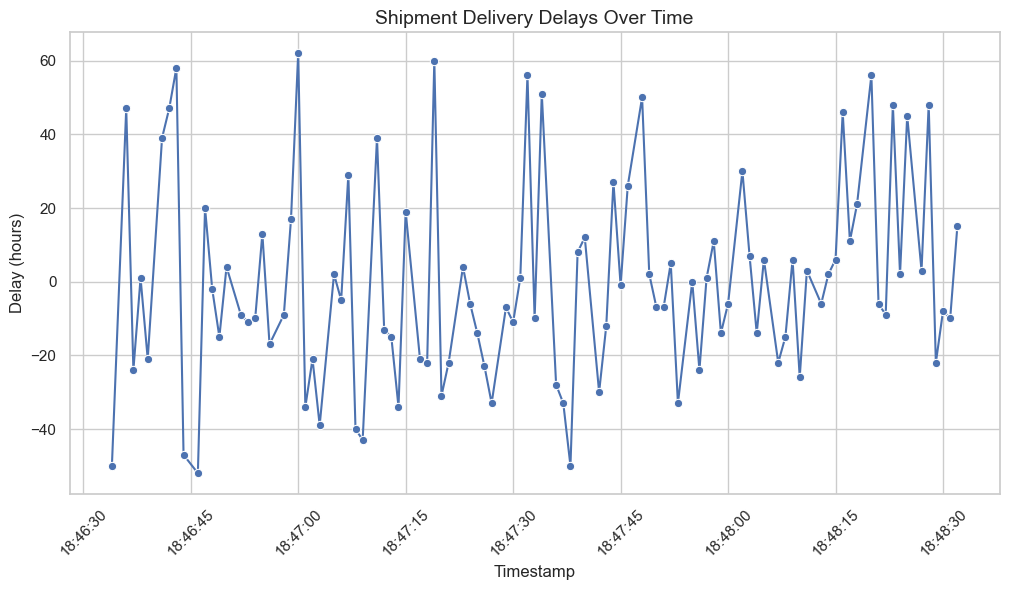

In [187]:
# --- Visualization 1: Delivery delays over time ---
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_cleaned["timestamp"], y=df_cleaned["delay_hours"], marker="o")
plt.xticks(rotation=45)
plt.title("Shipment Delivery Delays Over Time", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Delay (hours)", fontsize=12)
plt.show()

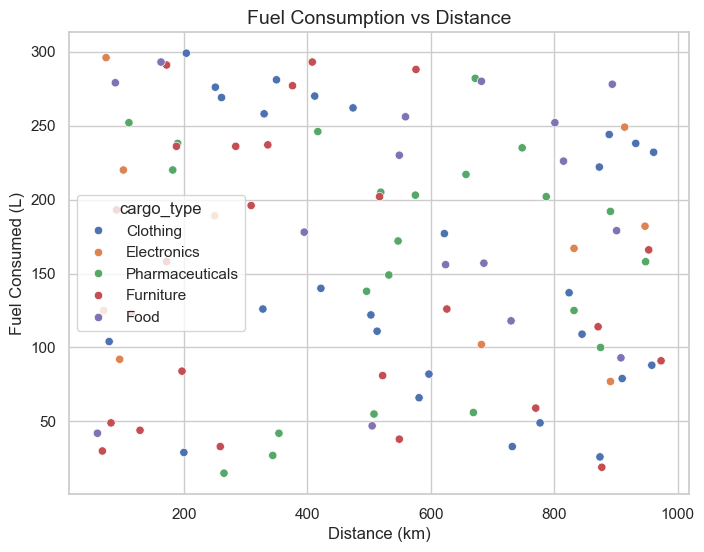

In [189]:
# --- Visualization 2: Fuel consumption vs distance ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_cleaned["distance_km"], y=df_cleaned["fuel_consumed_l"], hue=df_cleaned["cargo_type"])
plt.title("Fuel Consumption vs Distance", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Fuel Consumed (L)")
plt.show()

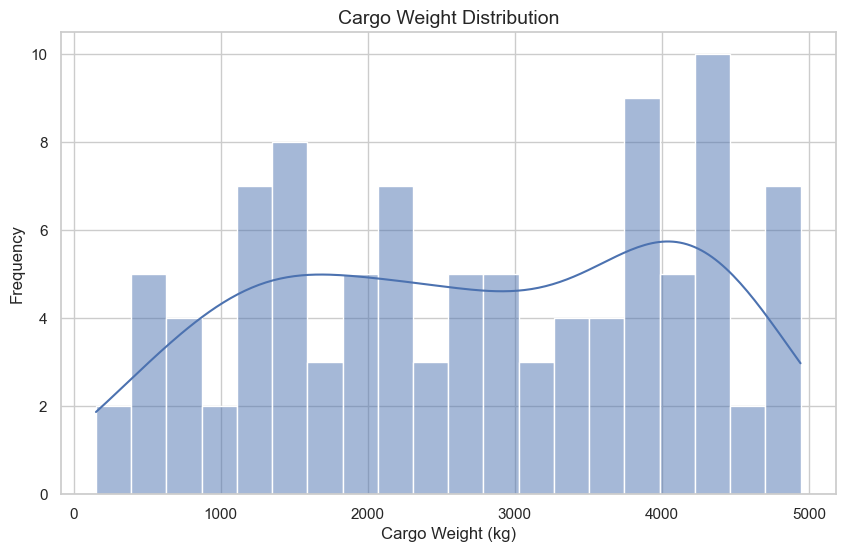

In [191]:
# --- Visualization: Cargo weight distribution ---
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned["cargo_weight_kg"], bins=20, kde=True)
plt.title("Cargo Weight Distribution", fontsize=14)
plt.xlabel("Cargo Weight (kg)")
plt.ylabel("Frequency")
plt.show()

C:\Users\jhoan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


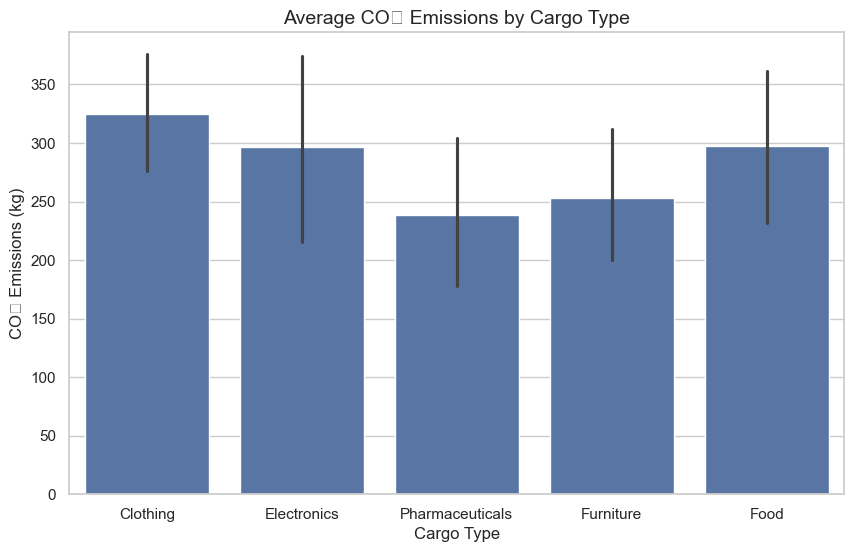

In [193]:
# --- Visualization: CO₂ emissions by cargo type ---
plt.figure(figsize=(10,6))
sns.barplot(x="cargo_type", y="co2_emissions_kg", data=df_cleaned, estimator="mean")
plt.title("Average CO₂ Emissions by Cargo Type", fontsize=14)
plt.xlabel("Cargo Type")
plt.ylabel("CO₂ Emissions (kg)")
plt.show()

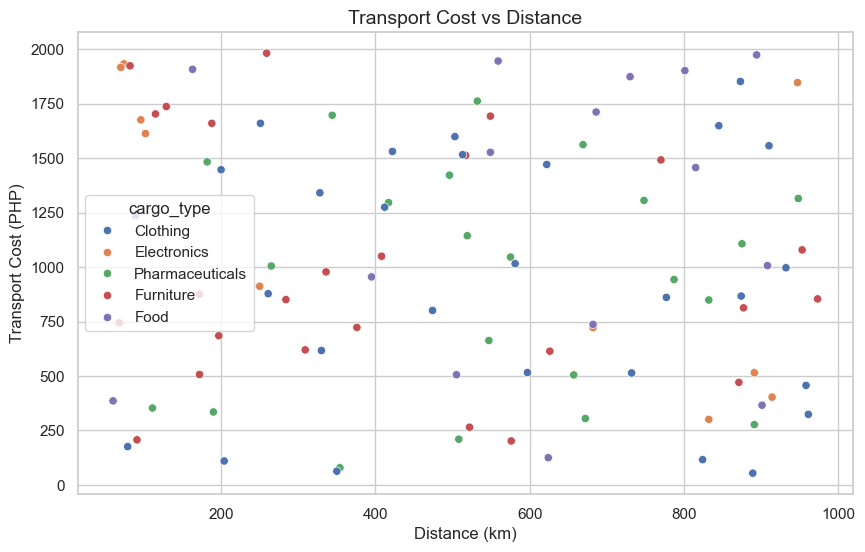

In [195]:
# --- Visualization: Transport cost vs distance ---
plt.figure(figsize=(10,6))
sns.scatterplot(x="distance_km", y="transport_cost_php", hue="cargo_type", data=df_cleaned)
plt.title("Transport Cost vs Distance", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Transport Cost (PHP)")
plt.show()

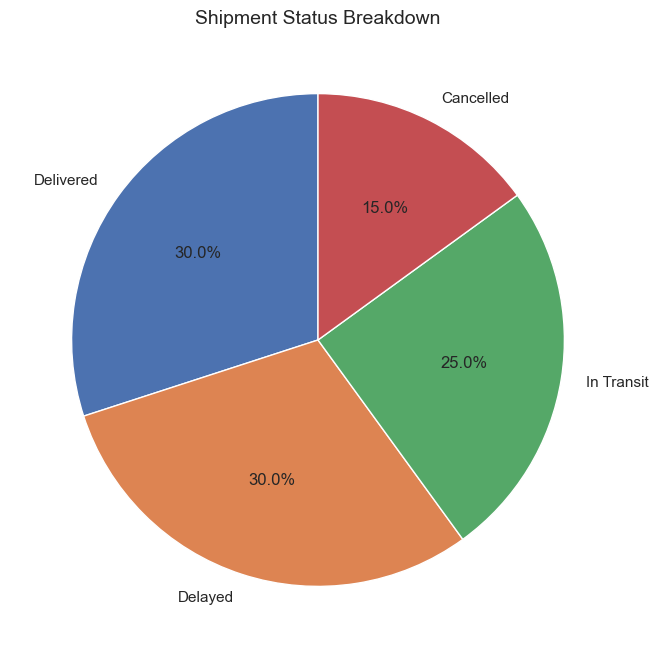

In [197]:
# --- Visualization: Status breakdown ---
plt.figure(figsize=(8,8))
df_cleaned["status"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Shipment Status Breakdown", fontsize=14)
plt.ylabel("")
plt.show()